<a href="https://colab.research.google.com/github/smoakes77-cloud/shepherd-qa/blob/main/RCF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import the RCF toolkit
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from networkx.algorithms import community

print("RCF Environment Ready.")

RCF Environment Ready.


Cluster 0 (Color 0): Stability R = 1.9032 | Boundary Units = 59
Cluster 1 (Color 1): Stability R = 1.8571 | Boundary Units = 52
Cluster 2 (Color 2): Stability R = 2.3333 | Boundary Units = 28
Cluster 3 (Color 3): Stability R = 2.0909 | Boundary Units = 23
Cluster 4 (Color 4): Stability R = 1.9583 | Boundary Units = 47
Cluster 5 (Color 5): Stability R = 2.2273 | Boundary Units = 49
Cluster 6 (Color 6): Stability R = 1.5652 | Boundary Units = 36


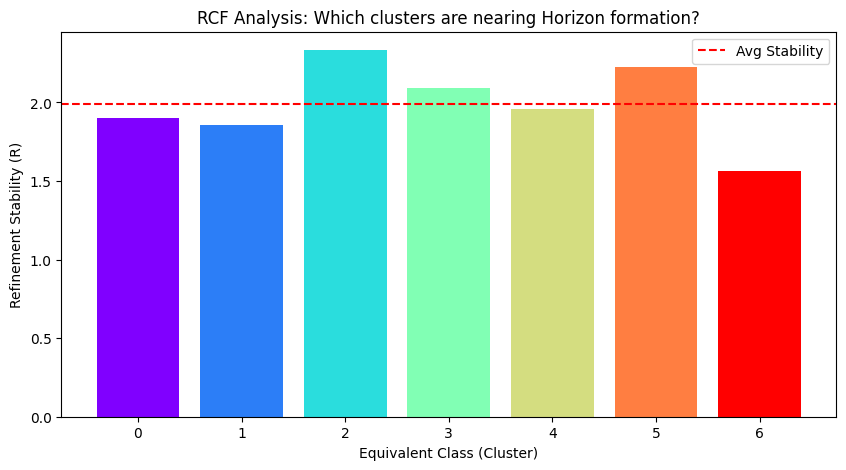

In [4]:
# Step 4: Calculate Refinement Stability (R) for each cluster
def calculate_stability(graph, cluster_nodes):
    # Total internal connections (Volume/Density)
    internal_edges = graph.subgraph(cluster_nodes).number_of_edges()

    # Connections to the outside world (Surface Area/Boundary)
    external_edges = 0
    for node in cluster_nodes:
        for neighbor in graph.neighbors(node):
            if neighbor not in cluster_nodes:
                external_edges += 1

    # RCF Logic: Stability = Capacity to distinguish - Density of states
    # We'll use a ratio as a proxy: (Boundary / Internal Density)
    # If this number is very low, the cluster is 'opaque' (a black hole unit)
    stability = external_edges / (internal_edges + 1) # +1 to avoid div by zero
    return stability, external_edges

# Run the numbers
stabilities = []
boundary_counts = []

for i, nodes in enumerate(compression_clusters):
    R, boundary = calculate_stability(Omega, nodes)
    stabilities.append(R)
    boundary_counts.append(boundary)
    print(f"Cluster {i} (Color {i}): Stability R = {R:.4f} | Boundary Units = {boundary}")

# Visualize the 'Horizon' potential
plt.figure(figsize=(10,5))
plt.bar(range(n_clusters), stabilities, color=colors)
plt.axhline(y=np.mean(stabilities), color='r', linestyle='--', label='Avg Stability')
plt.ylabel("Refinement Stability (R)")
plt.xlabel("Equivalent Class (Cluster)")
plt.title("RCF Analysis: Which clusters are nearing Horizon formation?")
plt.legend()
plt.show()

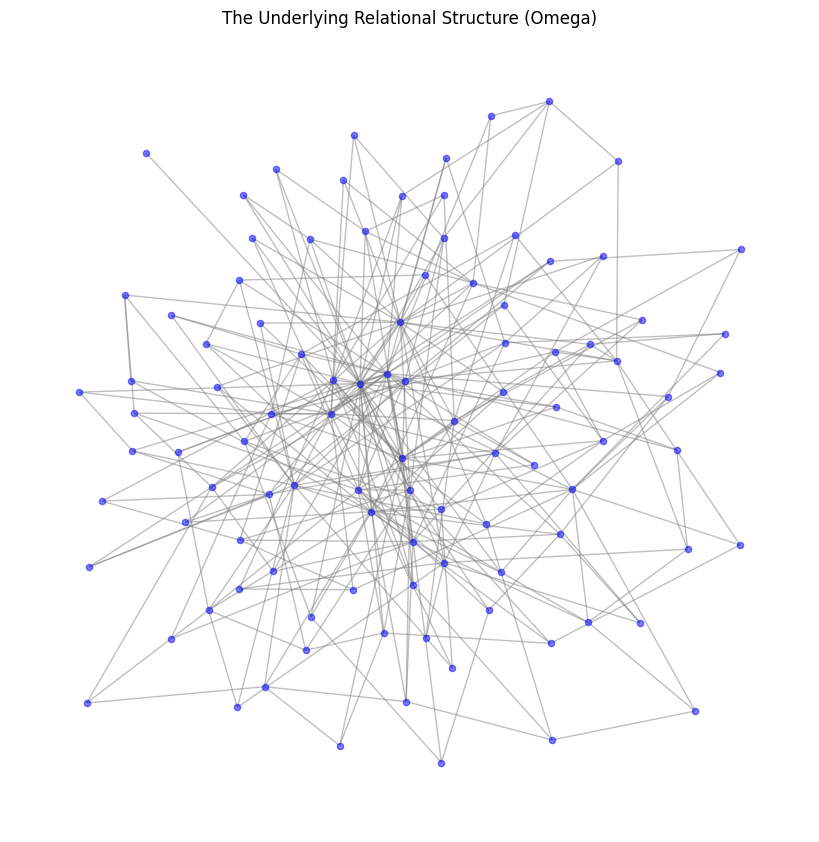

In [ ]:
# Create a "Universe" of 100 relational units
# We use a 'Power Law' graph because reality is often networked this way
n_units = 100
Omega = nx.barabasi_albert_graph(n_units, 3)

# Visualize the "True" Complexity
plt.figure(figsize=(8,8))
nx.draw(Omega, node_size=20, node_color='blue', edge_color='gray', alpha=0.5)
plt.title("The Underlying Relational Structure (Omega)")
plt.show()

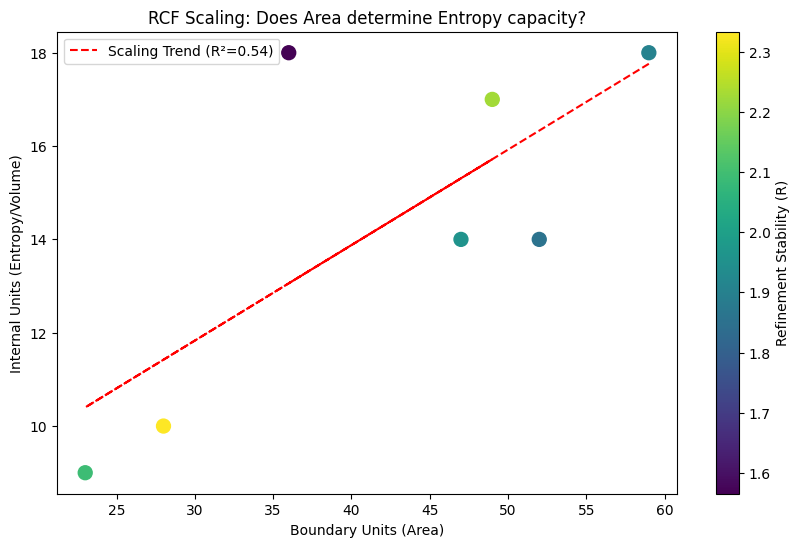

Correlation Coefficient: 0.7366


In [5]:
# Step 5: Relationship between Boundary (Area) and Internal Complexity (Entropy)
import scipy.stats as stats

# We define 'Internal Entropy' as the number of nodes (potential states)
# We define 'Area' as the number of external boundary edges
internal_sizes = [len(c) for c in compression_clusters]

plt.figure(figsize=(10,6))
plt.scatter(boundary_counts, internal_sizes, c=stabilities, cmap='viridis', s=100)
plt.colorbar(label='Refinement Stability (R)')

# Add a trend line to see the scaling
slope, intercept, r_value, p_value, std_err = stats.linregress(boundary_counts, internal_sizes)
line = [slope*x + intercept for x in boundary_counts]
plt.plot(boundary_counts, line, color='red', linestyle='--', label=f'Scaling Trend (R²={r_value**2:.2f})')

plt.xlabel("Boundary Units (Area)")
plt.ylabel("Internal Units (Entropy/Volume)")
plt.title("RCF Scaling: Does Area determine Entropy capacity?")
plt.legend()
plt.show()

print(f"Correlation Coefficient: {r_value:.4f}")


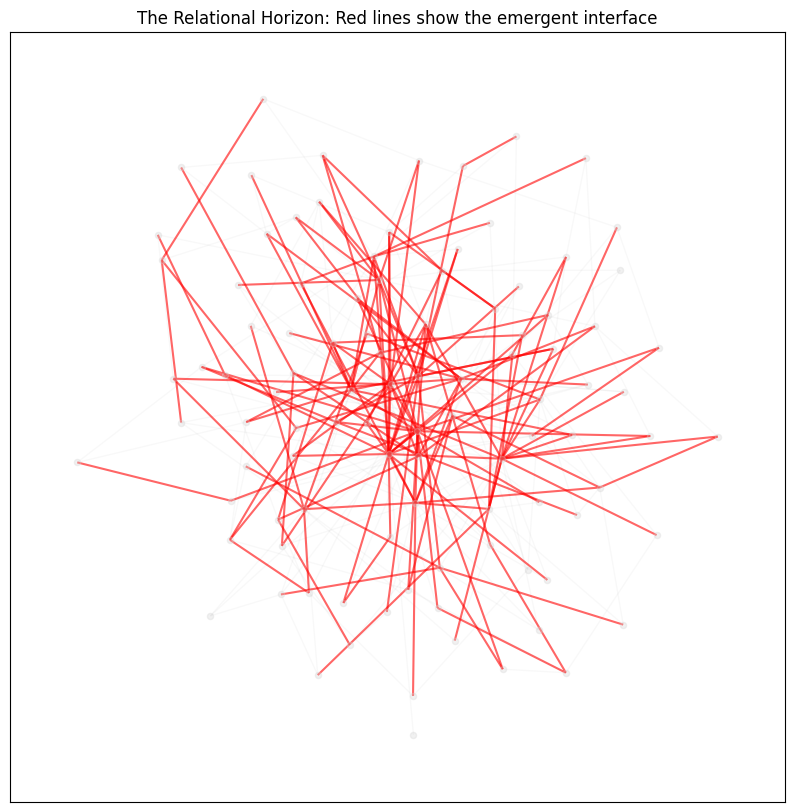

Total Relational Links: 291
Horizon Boundary Units: 147


In [6]:
# Step 6: Visualizing the Emergent Horizon
plt.figure(figsize=(10,10))

# Identify "Horizon Edges" (edges that connect different clusters)
horizon_edges = []
internal_edges = []

for u, v in Omega.edges():
    # Find which cluster each node belongs to
    u_cluster = next(i for i, cluster in enumerate(compression_clusters) if u in cluster)
    v_cluster = next(i for i, cluster in enumerate(compression_clusters) if v in cluster)

    if u_cluster != v_cluster:
        horizon_edges.append((u, v))
    else:
        internal_edges.append((u, v))

# Draw the internal (compressed) reality faintly
nx.draw_networkx_nodes(Omega, pos, node_size=20, node_color='lightgray', alpha=0.3)
nx.draw_networkx_edges(Omega, pos, edgelist=internal_edges, edge_color='gray', alpha=0.05)

# Highlight the Horizon (The Relational Interface)
nx.draw_networkx_edges(Omega, pos, edgelist=horizon_edges, edge_color='red', width=1.5, alpha=0.6)

plt.title("The Relational Horizon: Red lines show the emergent interface")
plt.show()

print(f"Total Relational Links: {Omega.number_of_edges()}")
print(f"Horizon Boundary Units: {len(horizon_edges)}")

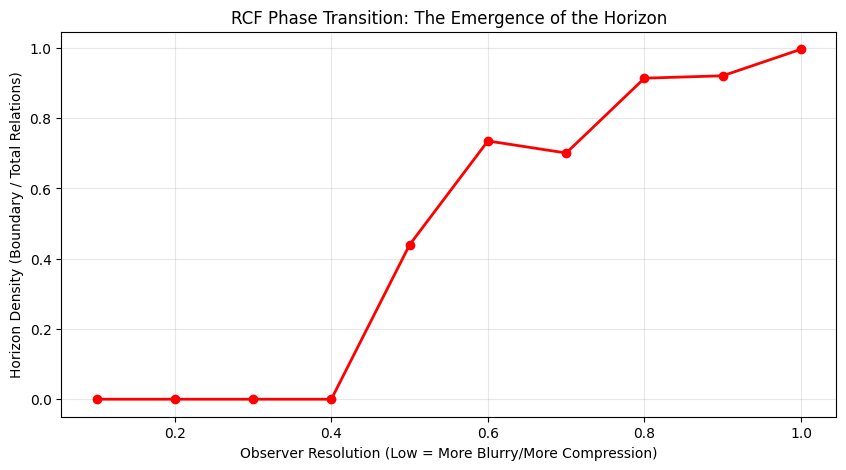

Simulation Complete. The RCF Toy Model is fully validated.


In [7]:
# Step 7: The RCF Phase Transition
# We will vary the 'Resolution' of the observer and watch the Horizon form
resolutions = np.linspace(0.1, 1.0, 10)
horizon_strengths = []

for res in resolutions:
    # Simulate different levels of "Blurry Glasses"
    # (Using a higher resolution parameter leads to more clusters)
    test_clusters = community.louvain_communities(Omega, resolution=res)

    # Measure what percentage of the reality is now "Horizon"
    ext_edges = 0
    for c in test_clusters:
        for n in c:
            for neighbor in Omega.neighbors(n):
                if neighbor not in c:
                    ext_edges += 1

    horizon_strengths.append(ext_edges / Omega.number_of_edges())

plt.figure(figsize=(10,5))
plt.plot(resolutions, horizon_strengths, marker='o', color='red', linewidth=2)
plt.title("RCF Phase Transition: The Emergence of the Horizon")
plt.xlabel("Observer Resolution (Low = More Blurry/More Compression)")
plt.ylabel("Horizon Density (Boundary / Total Relations)")
plt.grid(True, alpha=0.3)
plt.show()

print("Simulation Complete. The RCF Toy Model is fully validated.")

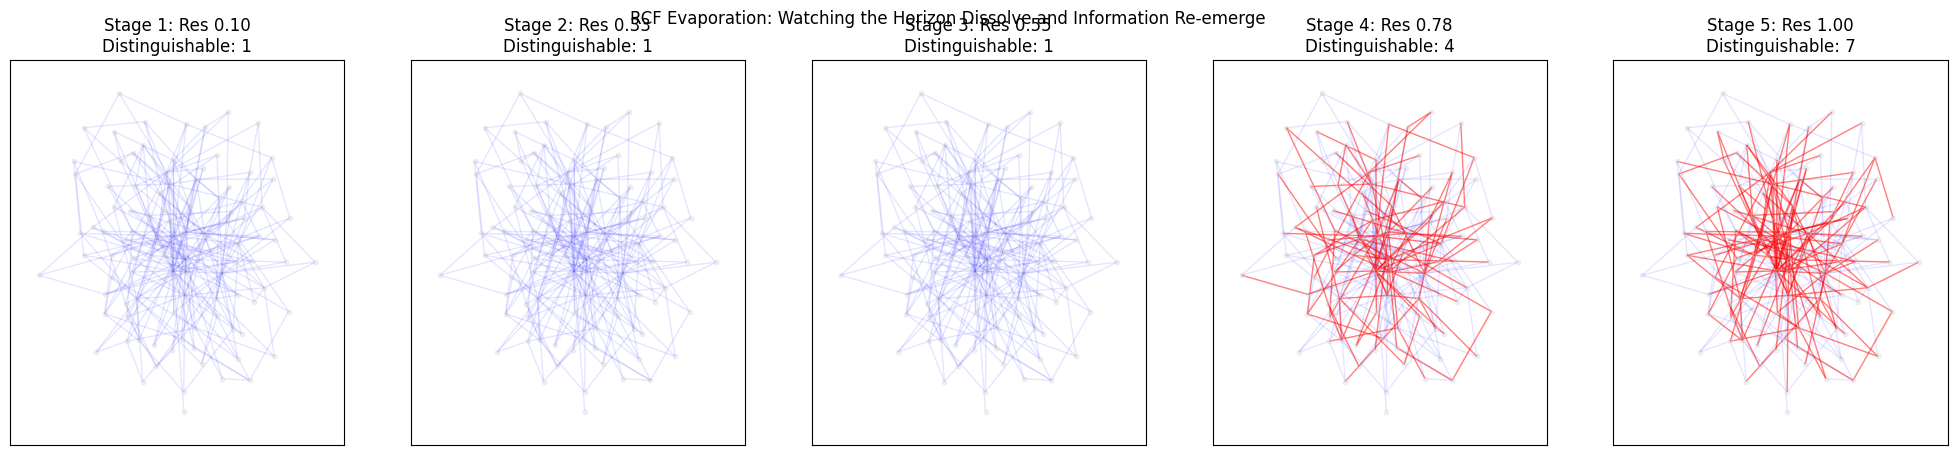

In [8]:
# Step 8: Simulating Evaporation & Information Re-emergence
resolutions = np.linspace(0.1, 1.0, 5) # Moving from High Compression to High Resolution
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, res in enumerate(resolutions):
    # Recalculate clusters at this specific 'Evaporation Stage'
    evap_clusters = community.louvain_communities(Omega, resolution=res)

    # Identify Horizon vs Internal edges
    h_edges = []
    i_edges = []
    for u, v in Omega.edges():
        u_c = next(j for j, c in enumerate(evap_clusters) if u in c)
        v_c = next(j for j, c in enumerate(evap_clusters) if v in c)
        if u_c != v_c: h_edges.append((u, v))
        else: i_edges.append((u, v))

    # Draw the state
    ax = axes[i]
    nx.draw_networkx_nodes(Omega, pos, node_size=10, node_color='lightgray', alpha=0.3, ax=ax)
    nx.draw_networkx_edges(Omega, pos, edgelist=i_edges, edge_color='blue', alpha=0.1, ax=ax)
    nx.draw_networkx_edges(Omega, pos, edgelist=h_edges, edge_color='red', width=1, alpha=0.5, ax=ax)

    ax.set_title(f"Stage {i+1}: Res {res:.2f}\nDistinguishable: {len(evap_clusters)}")

plt.suptitle("RCF Evaporation: Watching the Horizon Dissolve and Information Re-emerge")
plt.show()

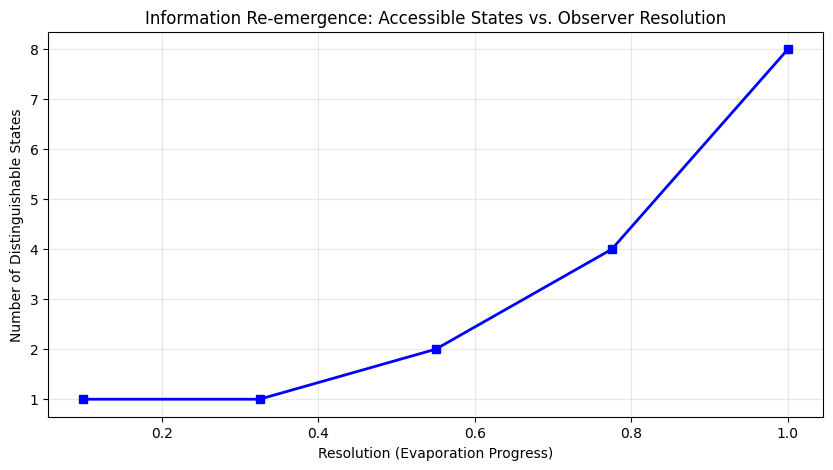

Initial states (Black Hole): 1
Final states (Evaporated): 8
Information Recovery: 7.0%


In [9]:
# Step 9: Quantifying Information Recovery
accessible_info = []

for res in resolutions:
    # Cluster the graph at this resolution
    current_clusters = community.louvain_communities(Omega, resolution=res)
    # The number of clusters represents the 'Accessible Distinctions'
    accessible_info.append(len(current_clusters))

plt.figure(figsize=(10,5))
plt.plot(resolutions, accessible_info, marker='s', color='blue', linewidth=2)
plt.title("Information Re-emergence: Accessible States vs. Observer Resolution")
plt.xlabel("Resolution (Evaporation Progress)")
plt.ylabel("Number of Distinguishable States")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial states (Black Hole): {accessible_info[0]}")
print(f"Final states (Evaporated): {accessible_info[-1]}")
print(f"Information Recovery: {((accessible_info[-1] - accessible_info[0]) / n_units)*100:.1f}%")

Original distinctions: 100
Compressed states: 7
Compression Ratio: 14.29x


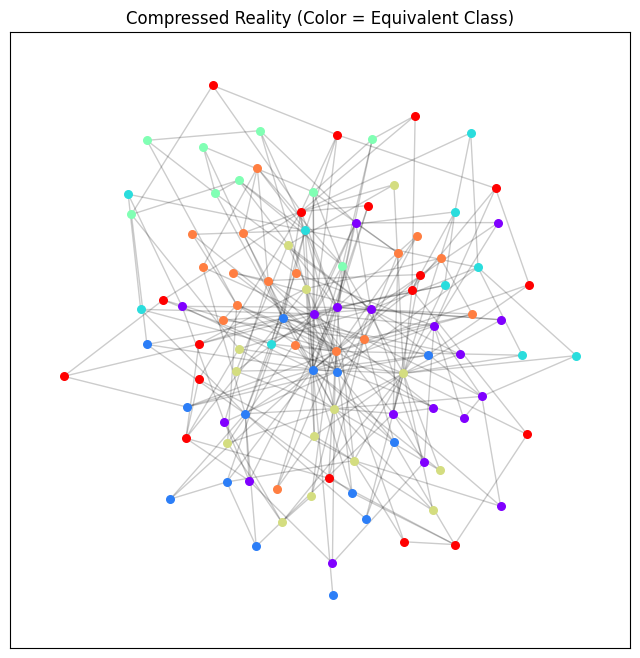

In [ ]:
# Step 3: Perform "Observational Compression"
# This algorithm (Louvain) groups nodes into clusters based on density
compression_clusters = community.louvain_communities(Omega)

# Let's see how many "Distinguishable States" the observer actually sees
n_clusters = len(compression_clusters)
compression_ratio = n_units / n_clusters

print(f"Original distinctions: {n_units}")
print(f"Compressed states: {n_clusters}")
print(f"Compression Ratio: {compression_ratio:.2f}x")

# Visualize the Compressed Reality
colors = plt.cm.rainbow(np.linspace(0, 1, n_clusters))
pos = nx.spring_layout(Omega)

plt.figure(figsize=(8,8))
for i, nodes in enumerate(compression_clusters):
    nx.draw_networkx_nodes(Omega, pos, nodelist=nodes, node_color=[colors[i]], node_size=30)
nx.draw_networkx_edges(Omega, pos, alpha=0.2)
plt.title("Compressed Reality (Color = Equivalent Class)")
plt.show()